In [1]:
from torchvision import datasets
import torch
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np #imports
device = 'cuda' if torch.cuda.is_available() else 'cpu' #gpu ou cpu
data_folder = 'data' 
fmnist = datasets.FashionMNIST(data_folder,download = True,train = True) #pega os dados
tr_images = fmnist.data 
tr_targets = fmnist.targets #imagens treino
val_fmnist = datasets.FashionMNIST(data_folder,download = True, train = False) #dados de teste

val_images = val_fmnist.data
val_targets = val_fmnist.targets #dados teste catalogados e as imagens

In [2]:
from imgaug import augmenters as iaa
aug = iaa.Sequential([
    iaa.Affine(translate_px={'x':(-10,10)}, #vai virnado a imagem
        mode='constant'), #coloca um valor constante em areas que nao tem nada
])

In [3]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y, aug=None):
        self.x, self.y = x, y
        self.aug = aug #
    def __getitem__(self, ix): #pega a imagem 
        x, y = self.x[ix], self.y[ix]
        return x, y
    def __len__(self): return len(self.x) #qtd de indice

    def collate_fn(self, batch): 
        ims, classes = list(zip(*batch)) #separa a imagem e a categoria dela
        if self.aug:
            ims_np = np.array([tensor.numpy() for tensor in ims])
            ims=self.aug.augment_images(images = ims_np) #modifica o batch 
            
        ims = torch.tensor(ims)[:,None,:,:].to(device)/255  #normaliza
        classes = torch.tensor(classes).to(device)
        return ims, classes

In [4]:
from torch.optim import SGD, Adam
def get_model(): #rede
    model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size = 3), #camada convolucional
        nn.MaxPool2d(2), #pooling
        nn.ReLU(), #ativacao
        nn.Conv2d(64, 128, kernel_size = 3), #camada convolucional
        nn.MaxPool2d(2), #pooling
        nn.ReLU(), #ativacao
        nn.Flatten(), #coloca em vetor
        nn.Linear(3200, 256), 
        nn.ReLU(), #ativacao
        nn.Linear(256, 10) 
    ).to(device)
    loss_fn = nn.CrossEntropyLoss() #perda
    optimizer = Adam(model.parameters(), lr = 1e-3) #otimizador
    return model, loss_fn, optimizer

In [5]:
def train_batch(x, y, model, opt, loss_fn):
    model.train() #treina
    prediction = model(x) #preve
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward() 
    optimizer.step()
    optimizer.zero_grad()  #pega os erros e atualiza os pesos, e zera o otimizador pro proximo batch
    return batch_loss.item()

In [6]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets, aug=aug) #cria o dataset pra treino
    trn_dl = DataLoader(train, batch_size=64, collate_fn=train.collate_fn, shuffle=True) #dataloader e emebaralhamento
    val = FMNISTDataset(val_images, val_targets) #pra teste
    val_dl = DataLoader(val, batch_size=len(val_images), collate_fn=val.collate_fn, shuffle=True) #loader de teste
    return trn_dl, val_dl

In [7]:
trn_dl, val_dl = get_data() #pega os dados
model, loss_fn, optimizer = get_model() #pega o modelo
for epoch in range(5): #5 epochs
    print(epoch)
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) #treina o modelo

0
1
2
3
4


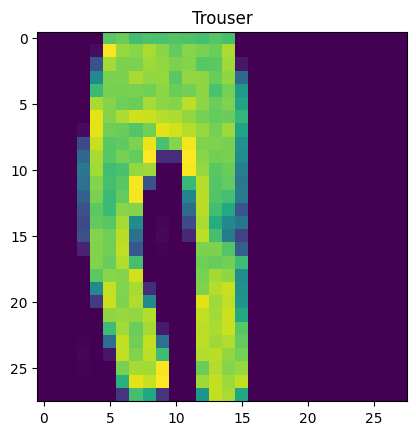

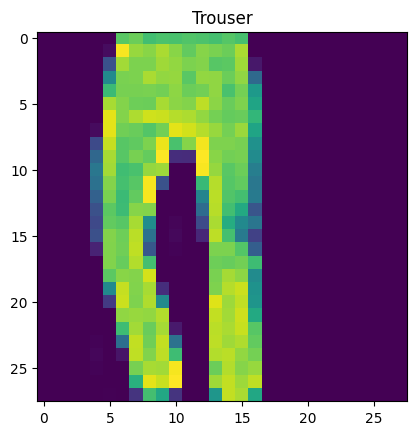

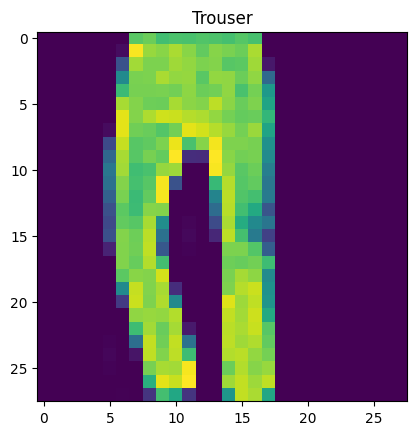

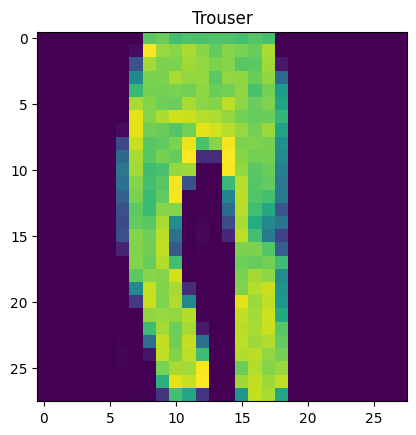

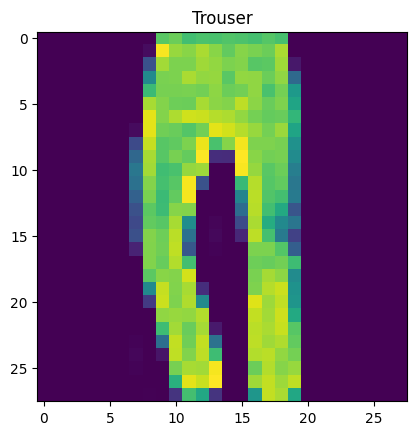

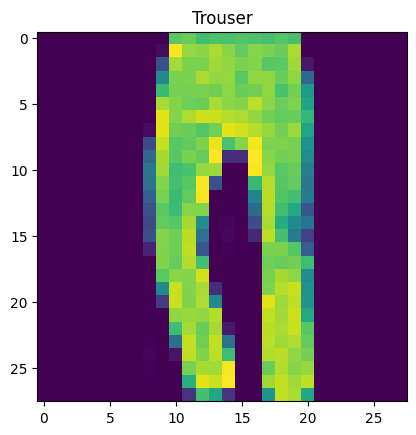

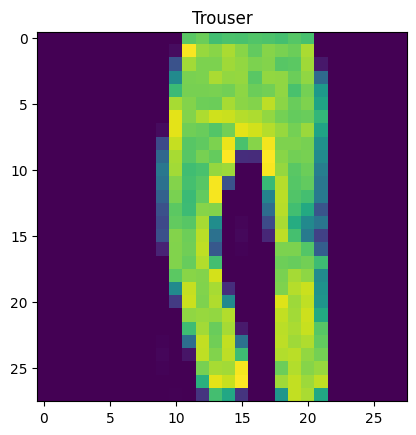

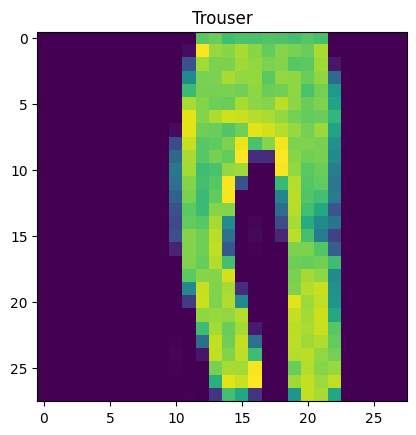

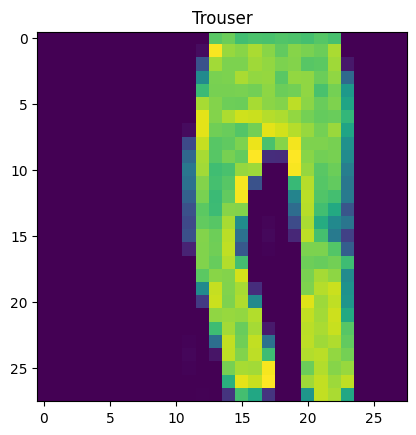

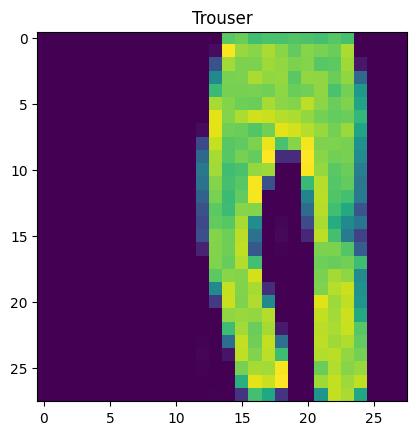

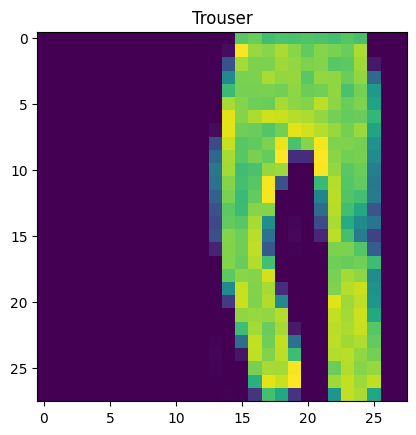

In [8]:
preds = [] #lista
ix = 24300 #imagem
for px in range(-5,6): #vai movendo ela pro lado
    img = tr_images[ix]/255.
    img = img.view(28, 28)
    img2 = np.roll(img, px, axis=1)
    img3 = torch.Tensor(img2).view(-1,1,28,28).to(device)
    np_output = model(img3).cpu().detach().numpy()
    pred = np.exp(np_output)/np.sum(np.exp(np_output))
    preds.append(pred)
    plt.imshow(img2)  #mostra a imagem indo pro lado
    plt.title(fmnist.classes[pred[0].argmax()])
    plt.show()